In [2]:
import matplotlib.pyplot as plt
import pvl
import numpy as np

from spectral.io import envi

In [ ]:
import os
import requests
from tqdm import tqdm
from bs4 import BeautifulSoup

# ==========================
# 🔹 CONFIG
# ==========================

base_dir = r"C:\Users\PhD24-2\Downloads\M3d1d2"
os.makedirs(base_dir, exist_ok=True)

product_ids = [
    "M3G20090426T001430_V01_RFL",
    "M3G20090426T041030_V01_RFL",
    "M3G20090426T061945_V01_RFL",
    "M3G20090426T080645_V01_RFL",
    "M3G20090426T120245_V01_RFL",
]

BASE_PDS = "https://pds-geosciences.wustl.edu/missions/m3/"

headers = {"User-Agent": "Mozilla/5.0"}


# ==========================
# 🔹 HELPERS
# ==========================

def get_date_folder(pid):
    return pid[3:11]


def get_volume_folders():
    # Known M3 volumes (expandable)
    return ["CH1M3_0003", "CH1M3_0004", "CH1M3_0005"]


def fetch_links_recursive(url):
    links = []
    try:
        r = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")

        for a in soup.find_all("a"):
            href = a.get("href")
            if not href or href.startswith("?"):
                continue

            full_url = url + href

            if href.endswith("/"):
                # go deeper
                links.extend(fetch_links_recursive(full_url))
            else:
                links.append(full_url)

    except:
        pass

    return links


def download_file(url, save_path):
    try:
        r = requests.get(url, headers=headers, stream=True, timeout=20)

        # skip HTML junk
        if "html" in r.headers.get("Content-Type", "").lower():
            return

        total = int(r.headers.get('content-length', 0))

        with open(save_path, 'wb') as f, tqdm(
            desc=os.path.basename(save_path),
            total=total,
            unit='B',
            unit_scale=True,
            leave=False
        ) as bar:
            for chunk in r.iter_content(1024):
                if chunk:
                    f.write(chunk)
                    bar.update(len(chunk))

    except:
        print(f"❌ Failed: {url}")


# ==========================
# 🔹 MAIN PIPELINE
# ==========================

x = 3  # start index

for pid in product_ids:

    print(f"\n⬇️ Processing {pid}")

    base_id = pid.replace("_V01_RFL", "")
    date_folder = get_date_folder(pid)

    dataset_dir = os.path.join(base_dir, f"M3D{x}")
    rfl_dir = os.path.join(dataset_dir, "RFL")
    loc_dir = os.path.join(dataset_dir, "LOC")

    os.makedirs(rfl_dir, exist_ok=True)
    os.makedirs(loc_dir, exist_ok=True)

    found = False

    # 🔥 search across volumes
    for volume in get_volume_folders():

        search_url = f"{BASE_PDS}{volume}/DATA/{date_folder}/"

        print(f"🔍 Searching in {volume}...")

        links = fetch_links_recursive(search_url)

        for link in links:
            filename = link.split("/")[-1]

            if base_id in filename:

                found = True

                if "RFL" in filename.upper():
                    save_path = os.path.join(rfl_dir, f"M3D{x}_{filename}")
                    download_file(link, save_path)

                elif "LOC" in filename.upper() or "GEO" in filename.upper():
                    save_path = os.path.join(loc_dir, f"M3D{x}_{filename}")
                    download_file(link, save_path)

    if not found:
        print(f"⚠️ No files found for {pid}")

    x += 1

print("\n🎉 DONE — All datasets processed.")


⬇️ Processing M3G20090426T001430_V01_RFL
🔍 Searching in CH1M3_0003...


In [3]:
# -------- Dataset 1 --------
hdr1 = r"C:/Users/PhD24-2/Downloads//M3d1d2/M3D1_V01_RFL.HDR"
img1 = r"C:/Users/PhD24-2/Downloads//M3d1d2/M3D1_V01_RFL.IMG"

img_obj1 = envi.open(hdr1, img1)
data1 = np.array(img_obj1.load())


# -------- Dataset 2 --------

hdr2 = r"C:/Users/PhD24-2/Downloads/M3d1d2/M3D2_V01_RFL.HDR"
img2 = r"C:/Users/PhD24-2/Downloads/M3d1d2/M3D2_V01_RFL.IMG"

img_obj2 = envi.open(hdr2, img2)
data2 = np.array(img_obj2.load())

print(data1.shape, data2.shape)

C:\Users\PhD24-2\anaconda3\Lib\site-packages\spectral\io\envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


(28770, 304, 85) (12066, 304, 85)


In [58]:
band1 = data1[:, :, 19]
band2 = data2[:, :, 19]

# remove invalid pixels
band1 = np.where(band1 < -900, np.nan, band1)
band2 = np.where(band2 < -900, np.nan, band2)

In [72]:
from spectral.io import envi

hdr1 = r"C:/Users/PhD24-2/Downloads/M3d1d2/M3D1_V01_LOC.HDR"
img_file1 = r"C:/Users/PhD24-2/Downloads/M3d1d2/M3D1_V01_LOC.IMG"

loc1 = envi.open(hdr1, img_file1)
loc_data1 = np.array(loc1.load())

print(loc_data1.shape)

print(loc1.metadata)

hdr2 = r"C:/Users/PhD24-2/Downloads/M3d1d2/M3D2_V01_LOC.HDR"
img_file2 = r"C:/Users/PhD24-2/Downloads/M3d1d2/M3D2_V01_LOC.IMG"

loc2 = envi.open(hdr2, img_file2)
loc_data2 = np.array(loc2.load())

print(loc_data2.shape)

print(loc2.metadata)



(28770, 304, 3)
{'description': 'M3 Level 1B Pixel Center Locations, MOON_ME frame, decimal degrees and\nmeters [Mon Nov 08 14:39:24 2010]', 'samples': '304', 'lines': '28770', 'bands': '3', 'header offset': '0', 'file type': 'ENVI Standard', 'data type': '5', 'interleave': 'bil', 'sensor type': 'Unknown', 'byte order': '0', 'wavelength units': 'Unknown', 'band names': ['Longitude', 'Latitude', 'Radius']}
(12066, 304, 3)
{'description': 'M3 Level 1B Pixel Center Locations, MOON_ME frame, decimal degrees and\nmeters [Mon Nov 08 16:32:12 2010]', 'samples': '304', 'lines': '12066', 'bands': '3', 'header offset': '0', 'file type': 'ENVI Standard', 'data type': '5', 'interleave': 'bil', 'sensor type': 'Unknown', 'byte order': '0', 'wavelength units': 'Unknown', 'band names': ['Longitude', 'Latitude', 'Radius']}


In [124]:
# D1
lon1 = loc1[:, :, 0]
lat1 = loc1[:, :, 1]
band1 = data1[:, :, 40]
lon1 = np.where(lon1 > 180, lon1 - 360, lon1)
# D2
lon2 = loc2[:, :, 0]
lat2 = loc2[:, :, 1]
band2 = data2[:, :, 40]
lon2 = np.where(lon2 > 180, lon2 - 360, lon2)

In [125]:
# Flatten everything
points1 = np.column_stack((lon1.flatten(), lat1.flatten()))
values1 = band1.flatten()

points2 = np.column_stack((lon2.flatten(), lat2.flatten()))
values2 = band2.flatten()

# Combine
points = np.vstack((points1, points2))
values = np.hstack((values1, values2))

mask = (
    (values > -900) &
    (~np.isnan(points[:,0])) &
    (~np.isnan(points[:,1]))
)

points = points[mask]
values = values[mask]

lat_grid = np.linspace(np.nanmin(points[:,1]), np.nanmax(points[:,1]), 700)
lon_grid = np.linspace(np.nanmin(points[:,0]), np.nanmax(points[:,0]), 300)

lon_g, lat_g = np.meshgrid(lon_grid, lat_grid)

In [126]:
from scipy.interpolate import griddata

grid = griddata(
    points,
    values,
    (lon_g, lat_g),
    method='linear'
)

In [127]:
from scipy.spatial import cKDTree

tree = cKDTree(points)
dist, _ = tree.query(np.column_stack((lon_g.ravel(), lat_g.ravel())))
dist = dist.reshape(lon_g.shape)

threshold = 0.03  # from your earlier calculation

grid = np.where(dist < threshold, grid, np.nan)

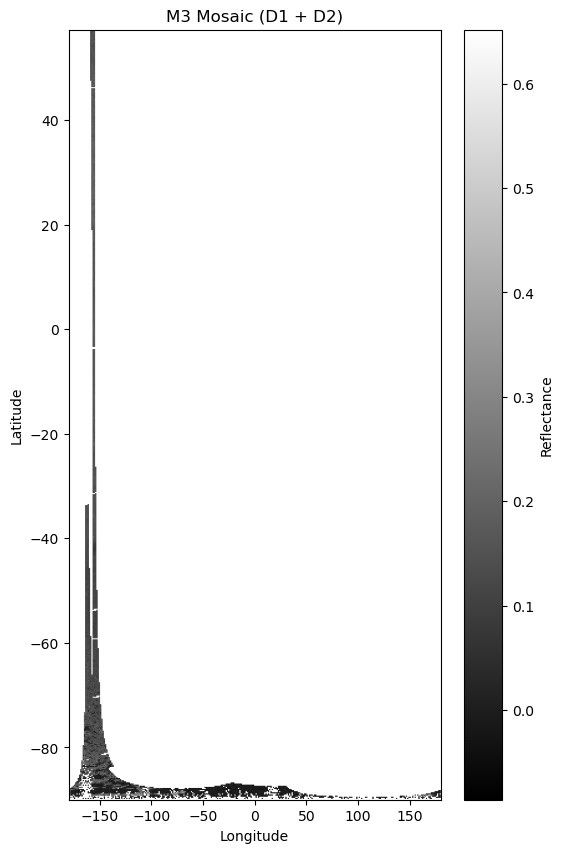

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,10))

plt.imshow(
    grid,
    extent=[lon_grid.min(), lon_grid.max(), lat_grid.min(), lat_grid.max()],
    origin='lower',
    cmap='gray',
    aspect='auto'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("M3 Mosaic (D1 + D2)")
plt.colorbar(label="Reflectance")

plt.show()

In [129]:
lat1 = np.array(lat1)
lon1 = np.array(lon1)
band1 = np.array(band1)

lat1_flat = lat1.flatten()
lon1_flat = lon1.flatten()
band1_flat = band1.flatten()


lat_threshold = 0   # keep only lat < 0

band1 = data1[:, :, 40]   # pick band index
band2 = data2[:, :, 40]

mask1 = lat1_flat < lat_threshold

points1 = np.column_stack((lon1_flat[mask1], lat1_flat[mask1]))
values1 = band1_flat[mask1]

lat2 = np.array(lat2)
lon2 = np.array(lon2)
band2 = np.array(band2)

lat2_flat = lat2.flatten()
lon2_flat = lon2.flatten()
band2_flat = band2.flatten()

mask2 = lat2_flat < lat_threshold

points2 = np.column_stack((lon2_flat[mask2], lat2_flat[mask2]))
values2 = band2_flat[mask2]

points = np.vstack((points1, points2))
values = np.hstack((values1, values2))

# Grid
lat_grid = np.linspace(np.nanmin(points[:,1]), np.nanmax(points[:,1]), 700)
lon_grid = np.linspace(np.nanmin(points[:,0]), np.nanmax(points[:,0]), 300)

lon_g, lat_g = np.meshgrid(lon_grid, lat_grid)

# Interpolation
from scipy.interpolate import griddata
grid = griddata(points, values, (lon_g, lat_g), method='linear')

# Mask artifacts
from scipy.spatial import cKDTree
tree = cKDTree(points)
dist, _ = tree.query(np.column_stack((lon_g.ravel(), lat_g.ravel())))
dist = dist.reshape(lon_g.shape)

threshold = 0.03
grid = np.where(dist < threshold, grid, np.nan)

In [130]:
# print(lat1.shape)
# print(band1.shape)
# print(data1.shape)

# print(points.shape)
# print(values.shape)

# print(mask1.shape)
# print(band1.shape)

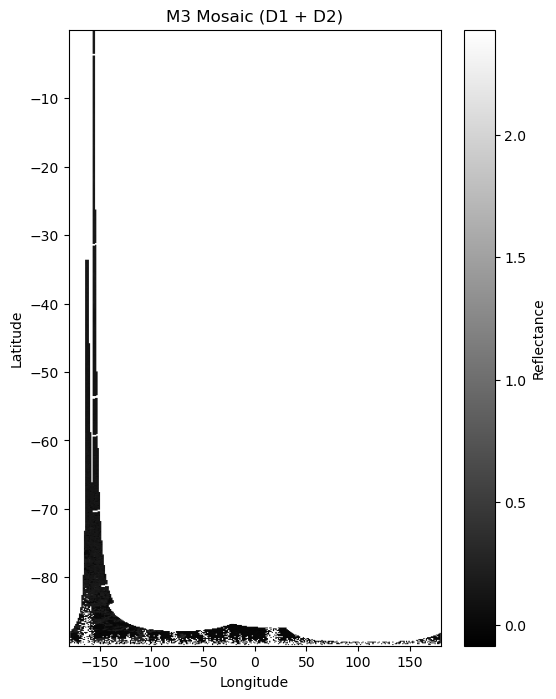

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,8))

plt.imshow(
    grid,
    extent=[lon_grid.min(), lon_grid.max(), lat_grid.min(), lat_grid.max()],
    origin='lower',
    cmap='gray',
    aspect='auto'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("M3 Mosaic (D1 + D2)")
plt.colorbar(label="Reflectance")

plt.show()

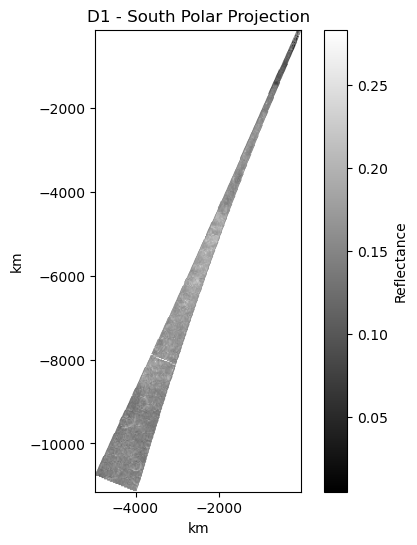

In [167]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.spatial import cKDTree

# --- Select band ---
band1 = data1[:, :, 40]

# --- Flatten ---
lat1_flat = lat1.flatten()
lon1_flat = lon1.flatten()
band1_flat = band1.flatten()

# --- Mask invalid ---
mask1 = band1_flat > -900

lat1_flat = lat1_flat[mask1]
lon1_flat = lon1_flat[mask1]
band1_flat = band1_flat[mask1]

# --- Convert to radians ---
lat_rad = np.radians(lat1_flat)
lon_rad = np.radians(lon1_flat)

# --- Lunar datum projection (South Polar) ---
R = 1737.4  # km

k = 2 * R / (1 - np.sin(lat_rad))

x1 = k * np.cos(lat_rad) * np.sin(lon_rad)
y1 = k * np.cos(lat_rad) * np.cos(lon_rad)

# --- Grid ---
xg = np.linspace(np.min(x1), np.max(x1), 400)
yg = np.linspace(np.min(y1), np.max(y1), 400)



X, Y = np.meshgrid(xg, yg)

# --- Interpolate ---
grid1 = griddata(
    np.column_stack((x1, y1)),
    band1_flat,
    (X, Y),
    method='linear'
)

# --- Mask artifacts ---
tree1 = cKDTree(np.column_stack((x1, y1)))
dist1, _ = tree1.query(np.column_stack((X.ravel(), Y.ravel())))
dist1 = dist1.reshape(X.shape)

grid1 = np.where(dist1 < 20, grid1, np.nan)

# --- Plot ---
plt.figure(figsize=(6,6))
plt.imshow(grid1, extent=[xg.min(), xg.max(), yg.min(), yg.max()],
           origin='lower', cmap='gray')
plt.title("D1 - South Polar Projection")
plt.xlabel("km")
plt.ylabel("km")
plt.colorbar(label="Reflectance")
plt.show()

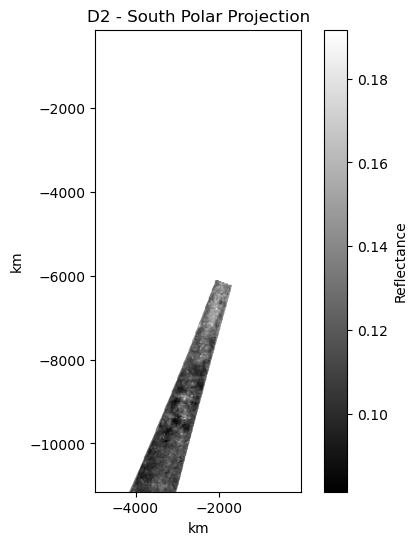

In [163]:
band2 = data2[:, :, 40]

lat2_flat = lat2.flatten()
lon2_flat = lon2.flatten()
band2_flat = band2.flatten()


mask2 = (band2_flat > -900)

lat2_flat = lat2_flat[mask2]
lon2_flat = lon2_flat[mask2]
band2_flat = band2_flat[mask2]

lat_rad = np.radians(lat2_flat)
lon_rad = np.radians(lon2_flat)

R = 1737.4

k = 2 * R / ((1 + np.sin(lat_rad)))

x2 = k * np.cos(lat_rad) * np.sin(lon_rad)
y2 = k * np.cos(lat_rad) * np.cos(lon_rad)

# IMPORTANT: use SAME grid as D1 for comparison
grid2 = griddata(
    np.column_stack((x2, y2)),
    band2_flat,
    (X, Y),
    method='linear'
)

tree2 = cKDTree(np.column_stack((x2, y2)))
dist2, _ = tree2.query(np.column_stack((X.ravel(), Y.ravel())))
dist2 = dist2.reshape(X.shape)

grid2 = np.where(dist2 < 20, grid2, np.nan)

# Plot
plt.figure(figsize=(6,6))
plt.imshow(grid2, extent=[xg.min(), xg.max(), yg.min(), yg.max()],
           origin='lower', cmap='gray')
plt.title("D2 - South Polar Projection")
plt.xlabel("km")
plt.ylabel("km")
plt.colorbar(label="Reflectance")
plt.show()

In [180]:
band2_flat = band2.flatten()
band1_flat = band1.flatten()

In [181]:
# Combine projected points
points_all = np.vstack((
    np.column_stack((x1, y1)),
    np.column_stack((x2, y2))
))

values_all = np.hstack((band1_flat, band2_flat))

grid_mosaic = griddata(
    points_all,
    values_all,
    (X, Y),
    method='linear'
)

tree_all = cKDTree(points_all)
dist_all, _ = tree_all.query(np.column_stack((X.ravel(), Y.ravel())))
dist_all = dist_all.reshape(X.shape)

grid_mosaic = np.where(dist_all < 20, grid_mosaic, np.nan)

ValueError: different number of values and points

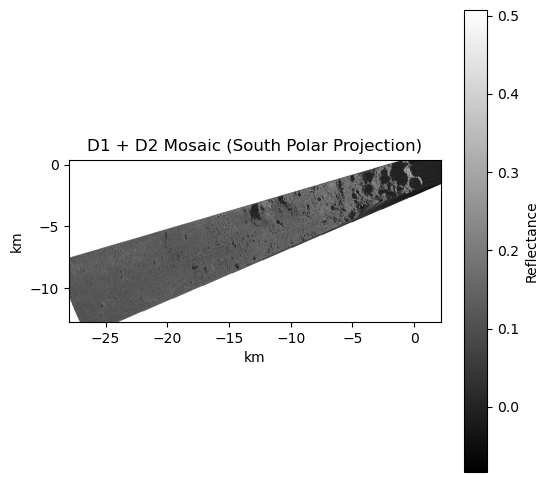

In [182]:
plt.figure(figsize=(6,6))

plt.imshow(
    grid_mosaic,
    extent=[xg.min(), xg.max(), yg.min(), yg.max()],
    origin='lower',
    cmap='gray'
)

plt.title("D1 + D2 Mosaic (South Polar Projection)")
plt.xlabel("km")
plt.ylabel("km")
plt.colorbar(label="Reflectance")

plt.show()

In [169]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.spatial import cKDTree

In [171]:
def process_dataset(lat, lon, data, band_index=40, lat_limit=-60):
    
    # --- Select band ---
    band = data[:, :, band_index]
    
    # --- Flatten ---
    lat_flat = lat.flatten()
    lon_flat = lon.flatten()
    band_flat = band.flatten()
    
    # --- Remove invalid ---
    mask = band_flat > -900
    
    lat_flat = lat_flat[mask]
    lon_flat = lon_flat[mask]
    band_flat = band_flat[mask]
    
    # --- Restrict to polar region ---
    mask = lat_flat < lat_limit
    
    lat_flat = lat_flat[mask]
    lon_flat = lon_flat[mask]
    band_flat = band_flat[mask]
    
    # --- Stable polar projection ---
    r = 90 + lat_flat
    theta = np.radians(lon_flat)
    
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    return x, y, band_flat

In [172]:
# D1
x1, y1, val1 = process_dataset(lat1, lon1, data1)

# D2
x2, y2, val2 = process_dataset(lat2, lon2, data2)

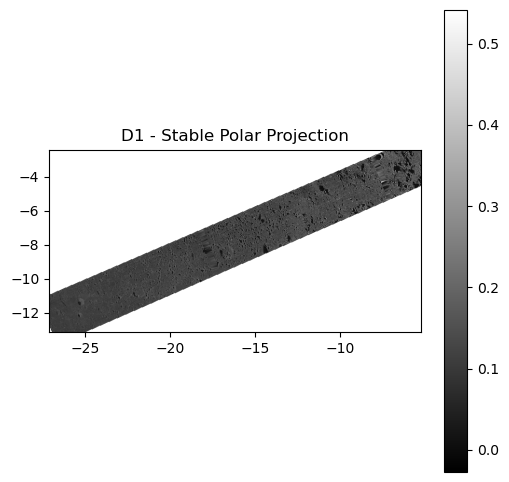

In [173]:
# Grid for D1
xg1 = np.linspace(np.percentile(x1, 1), np.percentile(x1, 99), 400)
yg1 = np.linspace(np.percentile(y1, 1), np.percentile(y1, 99), 400)

X1, Y1 = np.meshgrid(xg1, yg1)

grid1 = griddata(np.column_stack((x1, y1)), val1, (X1, Y1), method='linear')

# Mask artifacts
tree1 = cKDTree(np.column_stack((x1, y1)))
dist1, _ = tree1.query(np.column_stack((X1.ravel(), Y1.ravel())))
dist1 = dist1.reshape(X1.shape)

grid1 = np.where(dist1 < 1.5, grid1, np.nan)

# Plot
plt.figure(figsize=(6,6))
plt.imshow(grid1, extent=[xg1.min(), xg1.max(), yg1.min(), yg1.max()],
           origin='lower', cmap='gray')
plt.title("D1 - Stable Polar Projection")
plt.colorbar()
plt.show()

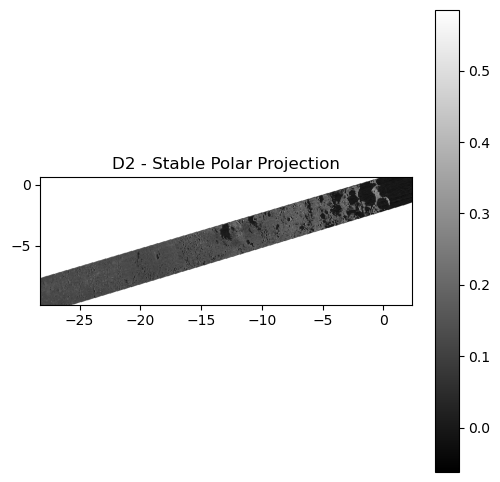

In [174]:
# Grid for D2
xg2 = np.linspace(np.percentile(x2, 1), np.percentile(x2, 99), 400)
yg2 = np.linspace(np.percentile(y2, 1), np.percentile(y2, 99), 400)

X2, Y2 = np.meshgrid(xg2, yg2)

grid2 = griddata(np.column_stack((x2, y2)), val2, (X2, Y2), method='linear')

# Mask artifacts
tree2 = cKDTree(np.column_stack((x2, y2)))
dist2, _ = tree2.query(np.column_stack((X2.ravel(), Y2.ravel())))
dist2 = dist2.reshape(X2.shape)

grid2 = np.where(dist2 < 1.5, grid2, np.nan)

# Plot
plt.figure(figsize=(6,6))
plt.imshow(grid2, extent=[xg2.min(), xg2.max(), yg2.min(), yg2.max()],
           origin='lower', cmap='gray')
plt.title("D2 - Stable Polar Projection")
plt.colorbar()
plt.show()

In [175]:
# Combine points
points_all = np.vstack((
    np.column_stack((x1, y1)),
    np.column_stack((x2, y2))
))

values_all = np.hstack((val1, val2))

# Common grid
xg = np.linspace(np.percentile(points_all[:,0], 1),
                 np.percentile(points_all[:,0], 99), 500)

yg = np.linspace(np.percentile(points_all[:,1], 1),
                 np.percentile(points_all[:,1], 99), 500)

X, Y = np.meshgrid(xg, yg)

# Interpolate
grid_mosaic = griddata(points_all, values_all, (X, Y), method='linear')

# Mask artifacts
tree = cKDTree(points_all)
dist, _ = tree.query(np.column_stack((X.ravel(), Y.ravel())))
dist = dist.reshape(X.shape)

grid_mosaic = np.where(dist < 1.5, grid_mosaic, np.nan)

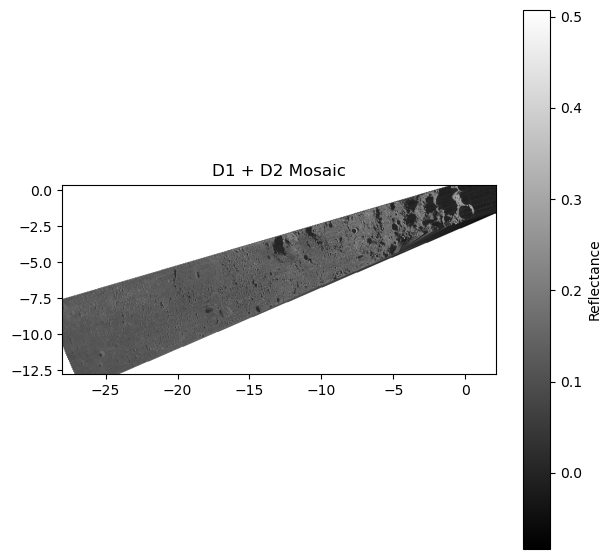

In [183]:
plt.figure(figsize=(7,7))

plt.imshow(
    grid_mosaic,
    extent=[xg.min(), xg.max(), yg.min(), yg.max()],
    origin='lower',
    cmap='gray'
)

plt.title("D1 + D2 Mosaic")
plt.colorbar(label="Reflectance")

plt.show()